In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [44]:
panel = pd.read_table("../../scratchhhh/consensus.all.tsv")
mutational_prof = pd.read_table("../../scratchhhh/all_samples.all.profile.tsv")
mutational_prof = mutational_prof.set_index("CONTEXT_MUT").rename(columns={"all_samples.all":"Probability"})

In [45]:
panel.head()

,CHROM,POS,REF,ALT,MUT_ID,GENE,IMPACT,CONTEXT_MUT,CONTEXT
0,chr1,26760730,A,C,chr1_26760730_A/C,ARID1A,intron_variant,TTA>G,TTA
1,chr1,26760730,A,G,chr1_26760730_A/G,ARID1A,intron_variant,TTA>C,TTA
2,chr1,26760730,A,T,chr1_26760730_A/T,ARID1A,intron_variant,TTA>A,TTA
3,chr1,26760731,A,C,chr1_26760731_A/C,ARID1A,intron_variant,TTT>G,TTT
4,chr1,26760731,A,G,chr1_26760731_A/G,ARID1A,intron_variant,TTT>C,TTT


In [46]:
mutational_prof

,Probability
CONTEXT_MUT,
ACA>A,0.006140
ACC>A,0.006306
ACG>A,0.008522
ACT>A,0.003870
CCA>A,0.004002
...,...
GTT>G,0.002068
TTA>G,0.001822
TTC>G,0.001456


In [47]:
def triplet_context_iterator():
    subs = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G']
    flanks = ['AA', 'AC', 'AG', 'AT', 'CA', 'CC', 'CG', 'CT',
              'GA', 'GC', 'GG', 'GT', 'TA', 'TC', 'TG', 'TT']
    contexts = []
    for sub in subs:
        for flank in flanks:
            contexts.append( flank[0] + sub[0] + flank[1] + '>' + sub[-1])

    return contexts
    


In [ ]:
# we need a stable background mutation density estimation,
# for this we need at least 3 mutations

def mutation_based_assessment(panel_tsv, expected_mutation_density_in_mb, samples, depth, mutational_profile = None):
    if mutational_profile is None:
        mutational_profile = pd.DataFrame(np.ones(96) / 96)
        mutational_profile.index = triplet_context_iterator()
    mutational_profile = mutational_profile / mutational_profile.mean()
    mutational_profile.columns = ["Probability"]

    size_per_consequence = panel_tsv.groupby(by = ["GENE", "IMPACT", "CONTEXT_MUT"]).size().reset_index(name = "DEPTH")
    size_per_consequence["DEPTH"] *= depth/3

    size_per_consequence = size_per_consequence.merge(mutational_profile,
                                                      left_on = "CONTEXT_MUT",
                                                      right_index = True,
                                                      how = "left")
    size_per_consequence["ADJUSTED_DEPTH"] = size_per_consequence["DEPTH"] * size_per_consequence["Probability"]

    total_adjusted_size = size_per_consequence.groupby(by = ["GENE", "IMPACT"])["ADJUSTED_DEPTH"].sum() / 3
    expected_mutations_per_cnsq = (expected_mutation_density_in_mb * total_adjusted_size * samples) / 1e6

    return expected_mutations_per_cnsq

In [61]:
mutations_per_gene_consequence = mutation_based_assessment(panel, 1.2, 100, 5000)
mutations_per_gene_consequence_mut_prof = mutation_based_assessment(panel, 1.2, 100, 5000, mutational_prof)
mutations_per_gene_consequence.head()

    GENE             IMPACT CONTEXT_MUT         DEPTH  Probability
0  AK4P1  non_genic_variant       ACA>A  45000.000000          1.0
1  AK4P1  non_genic_variant       ACA>G  45000.000000          1.0
2  AK4P1  non_genic_variant       ACA>T  45000.000000          1.0
3  AK4P1  non_genic_variant       ACC>A  16666.666667          1.0
4  AK4P1  non_genic_variant       ACC>G  16666.666667          1.0
    GENE             IMPACT CONTEXT_MUT         DEPTH  Probability
0  AK4P1  non_genic_variant       ACA>A  45000.000000     0.589399
1  AK4P1  non_genic_variant       ACA>G  45000.000000     0.260531
2  AK4P1  non_genic_variant       ACA>T  45000.000000     1.097649
3  AK4P1  non_genic_variant       ACC>A  16666.666667     0.605390
4  AK4P1  non_genic_variant       ACC>G  16666.666667     0.190889


GENE   IMPACT           
AK4P1  non_genic_variant    125.400000
ALK    essential_splice       2.000000
       intron_variant       509.800000
       missense              41.933333
       nonsense               1.866667
Name: ADJUSTED_DEPTH, dtype: float64

In [62]:
consequences_to_plot = ['synonymous', 'missense', 'nonsense',
                        'essential_splice', 'splice_region_variant', 
                        # 'non_genic_variant',  'intron_variant',
                        # 'non_coding_exon_region', 'non_coding_transcript_variant'
                        ]

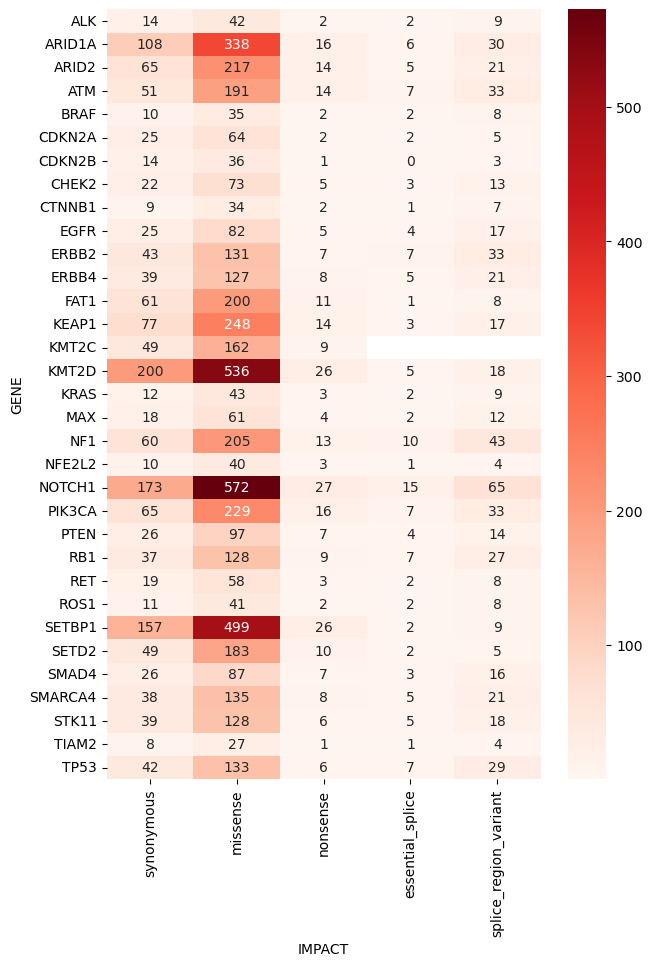

In [63]:
#plot mutations_per_gene_consequence as a heatmap
data_to_plot = mutations_per_gene_consequence.unstack(level=0).loc[consequences_to_plot]
data_to_plot = data_to_plot[[x for x in data_to_plot.columns if not data_to_plot[x].isna().all()]].T
plt.figure(figsize=(7, 10))
sns.heatmap(data_to_plot, annot=True, fmt=".0f", cmap="Reds")
plt.show()

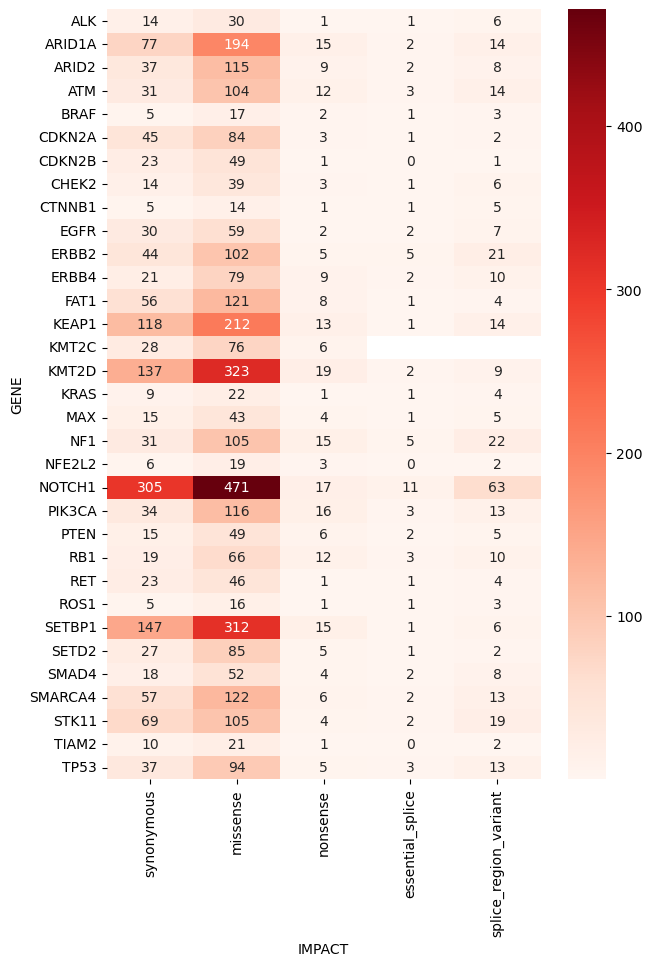

In [64]:
#plot mutations_per_gene_consequence as a heatmap
data_to_plot = mutations_per_gene_consequence_mut_prof.unstack(level=0).loc[consequences_to_plot]
data_to_plot = data_to_plot[[x for x in data_to_plot.columns if not data_to_plot[x].isna().all()]].T
plt.figure(figsize=(7, 10))
sns.heatmap(data_to_plot, annot=True, fmt=".0f", cmap="Reds")
plt.show()

In [ ]:



# we need a stable background mutation density estimation,
# for this we need at least 3 mutations

def mutation_based_assessment(panel_tsv, expected_mutation_density_in_mb, samples, depth, mutational_profile = None):
    if mutational_profile is None:
        mutational_profile = np.ones(96) / 96

    size_per_consequence = panel_tsv.groupby(by = ["consequence", "CONTEXT_MUT"]).size().reset_index(name = "DEPTH")
    size_per_consequence["DEPTH"] *= depth
    mutational_profile = mutational_profile / mutational_profile.mean()
    size_per_consequence = size_per_consequence.merge(mutational_profile,
                                                      left_on = "CONTEXT_MUT",
                                                      right_index = True,
                                                      how = "left",
                                                      suffixes = ("", "_MP"))
    size_per_consequence["ADJUSTED_DEPTH"] = size_per_consequence["DEPTH"] * size_per_consequence["0_MP"]

    total_adjusted_size = size_per_consequence.groupby("consequence")["ADJUSTED_DEPTH"].sum()
    expected_mutations_per_cnsq = (expected_mutation_density_in_mb * total_adjusted_size * samples) / 1e6

    return expected_mutations_per_cnsq


signatures_based_assessment

def assess_panel(panel_tsv, expected_mutation_density_in_mb, samples, depth, mutational_profile = None):
    mutation_based_assessment(panel_tsv, expected_mutation_density_in_mb, samples, depth, mutational_profile)
    mutation_based_assessment(panel_tsv, expected_mutation_density_in_mb, samples, depth, None)

    signatures_based_assessment(panel_tsv, expected_mutation_density_in_mb, samples, depth, mutational_profile)
